# Lab 1 — Complex Baseband, IQ Sampling and the SDR Receive Chain

**Companion to Chapter 1.** By the end of this lab you will be able to:

1. Move a signal between passband and complex baseband and explain why the
   baseband spectrum can be asymmetric.
2. Predict how DC offset and IQ imbalance in a direct-conversion receiver such
   as the B200's AD9364 appear in the spectrum, and compute image rejection.
3. Relate ADC resolution, gain setting and noise figure to the usable dynamic range.
4. Load a real IQ capture made with `gnuradio/gr01_spectrum_iq_capture.py`.

Every figure below is regenerated from code you can edit. Sliders appear in the
sections marked **Interactive**; run the notebook in JupyterLab to use them.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import commlib as cl

cl.style()
rng = np.random.default_rng(1)

## 1. Passband ↔ baseband

A real bandpass signal can always be written as
$x(t) = \mathrm{Re}\{\tilde{x}(t)\,e^{j2\pi f_c t}\} = x_I(t)\cos 2\pi f_c t - x_Q(t)\sin 2\pi f_c t$.
The complex envelope $\tilde{x} = x_I + j x_Q$ carries all the information at
a sample rate set by the *bandwidth*, not the carrier.

Below we build a two-tone baseband signal with tones at **+100 Hz** and
**−250 Hz**. In baseband these are distinct; after up-conversion they sit at
$f_c+100$ and $f_c-250$. A real-valued baseband could never represent this
asymmetric spectrum, which is exactly why receivers sample I and Q.

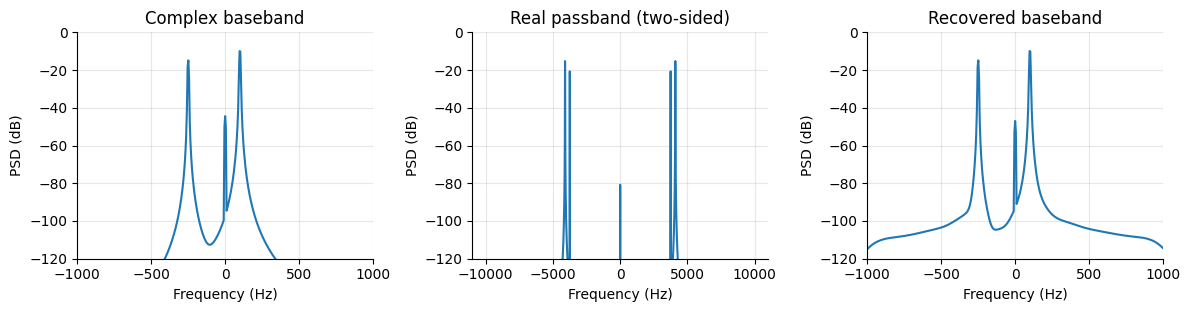

In [3]:
fs_rf = 20_000          # "RF" simulation rate (Hz) for the passband signal
fc = 4_000              # carrier (Hz)
t = np.arange(0, 0.5, 1 / fs_rf)
xb = np.exp(2j * np.pi * 100 * t) + 0.5 * np.exp(-2j * np.pi * 250 * t)
xp = np.real(xb * np.exp(2j * np.pi * fc * t))          # real passband

# Down-conversion: mix with e^{-j 2 pi fc t}, then low-pass filter
from scipy.signal import firwin, lfilter
lpf = firwin(201, 1_000, fs=fs_rf)
xr = lfilter(lpf, 1, 2 * xp * np.exp(-2j * np.pi * fc * t))

fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
cl.plot_psd(ax[0], xb, fs_rf, 4096); ax[0].set_title("Complex baseband"); ax[0].set_xlim(-1000, 1000)
cl.plot_psd(ax[1], xp, fs_rf, 4096); ax[1].set_title("Real passband (two-sided)")
cl.plot_psd(ax[2], xr, fs_rf, 4096); ax[2].set_title("Recovered baseband"); ax[2].set_xlim(-1000, 1000)
for a in ax: a.set_ylim(-120, 0)
plt.tight_layout(); plt.show()

Notice that the real passband PSD is Hermitian-symmetric (mirror images around
0 Hz), and that down-conversion produces a copy at $-2f_c$ that the low-pass
filter removes. The factor of 2 in the mixer restores the original amplitude.

## 2. Sampling complex baseband: the Nyquist zone is $[-f_s/2, f_s/2)$

With complex sampling, a tone at $f$ aliases to $((f + f_s/2) \bmod f_s) - f_s/2$.
Unlike real sampling there is no folding, only wrapping. This matters on the B200:
when you tune to 915 MHz with 1 MS/s, a signal at 915.7 MHz appears at −300 kHz
if the anti-alias filter does not remove it.

In [6]:
def alias(f, fs):
    return ((f + fs / 2) % fs) - fs / 2

fs = 1e6
for f in [100e3, 450e3, 700e3, -600e3, 1.3e6]:
    print(f"tone at {f/1e3:7.0f} kHz  ->  appears at {alias(f, fs)/1e3:7.0f} kHz")

tone at     100 kHz  ->  appears at     100 kHz
tone at     450 kHz  ->  appears at     450 kHz
tone at     700 kHz  ->  appears at    -300 kHz
tone at    -600 kHz  ->  appears at     400 kHz
tone at    1300 kHz  ->  appears at     300 kHz


## 3. Direct-conversion impairments: DC offset and IQ imbalance

The AD9364 in the B200 is a zero-IF transceiver. Two artefacts follow directly:

* **LO leakage / DC offset** puts a spur at 0 Hz. UHD runs automatic DC-offset
  correction by default, but a small residual always remains, which is why many
  SDR designs tune a few hundred kHz away from the signal of interest.
* **IQ gain/phase mismatch** turns $y = \mu x + \nu x^*$. The conjugate term is a
  mirror *image* at $-f$. The image rejection ratio is
  $\mathrm{IRR} = |\mu|^2 / |\nu|^2$.

### Interactive: impairments in the spectrum
Move the sliders. For a 0.5 dB / 3° mismatch the IRR is about 28 dB; typical
calibrated transceivers reach 40–60 dB.

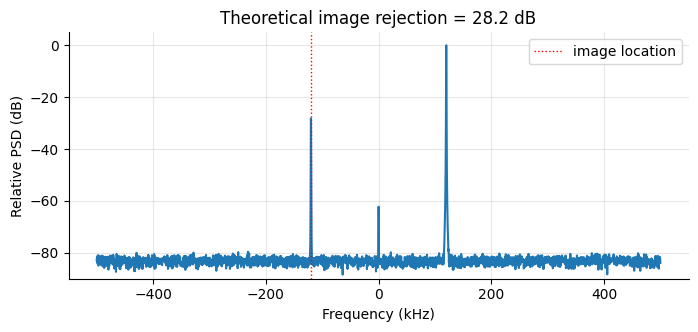

In [8]:
N = 1 << 15
n = np.arange(N)

def impairments(tone_khz=120.0, gain_db=0.5, phase_deg=3.0, dc=0.02, snr_db=50.0):
    x = np.exp(2j * np.pi * tone_khz * 1e3 / fs * n)
    y = cl.iq_imbalance(x, gain_db, phase_deg) + dc * (1 + 1j)
    y = cl.awgn(y, snr_db, rng)
    g = 10 ** (gain_db / 20); phi = np.deg2rad(phase_deg)
    mu = (1 + g * np.exp(1j * phi)) / 2; nu = (1 - g * np.exp(-1j * phi)) / 2
    irr = 10 * np.log10(abs(mu) ** 2 / max(abs(nu) ** 2, 1e-15))
    fig, ax = plt.subplots(figsize=(8, 3.2))
    f, p = cl.welch_psd(y, fs, 4096)
    ax.plot(f / 1e3, p - p.max())
    ax.axvline(-tone_khz, color="r", ls=":", lw=1, label="image location")
    ax.set_xlabel("Frequency (kHz)"); ax.set_ylabel("Relative PSD (dB)")
    ax.set_title(f"Theoretical image rejection = {irr:.1f} dB"); ax.set_ylim(-90, 5)
    ax.legend(); plt.show()

interact(impairments,
         tone_khz=FloatSlider(value=120, min=-450, max=450, step=10, description="tone kHz"),
         gain_db=FloatSlider(value=0.5, min=0, max=3, step=0.1, description="gain dB"),
         phase_deg=FloatSlider(value=3, min=0, max=15, step=0.5, description="phase °"),
         dc=FloatSlider(value=0.02, min=0, max=0.3, step=0.01, description="DC"),
         snr_db=FloatSlider(value=50, min=10, max=80, step=5, description="SNR dB"));

## 4. Dynamic range: ADC bits, gain and noise figure

An ideal $b$-bit ADC driven by a full-scale sine has SQNR $\approx 6.02b + 1.76$ dB,
about 74 dB for the B200's 12-bit converters, plus processing gain
$10\log_{10}(f_s / 2B)$ when you decimate to a bandwidth $B$.
The analog noise floor is $-174 + 10\log_{10}B + \mathrm{NF}$ dBm. Receiver gain
should be set so that the thermal noise sits a few ADC LSBs above the
quantization floor, but strong signals do not clip.

In [10]:
def quantize(x, bits, full_scale=1.0):
    q = 2 * full_scale / 2 ** bits
    clip = lambda v: np.clip(v, -full_scale, full_scale - q)
    return q * np.round(clip(x.real) / q) + 1j * q * np.round(clip(x.imag) / q)

x = 0.9 * np.exp(2j * np.pi * 0.0123 * np.arange(1 << 16))
for b in [4, 8, 12, 16]:
    e = quantize(x, b) - x
    print(f"{b:2d} bits: measured SQNR = {10*np.log10(np.mean(abs(x)**2)/np.mean(abs(e)**2)):5.1f} dB")

 4 bits: measured SQNR =  25.5 dB
 8 bits: measured SQNR =  49.2 dB
12 bits: measured SQNR =  73.2 dB
16 bits: measured SQNR =  97.1 dB


### Interactive: receiver noise floor and sensitivity
For a signal bandwidth $B$, noise figure NF and required SNR, the sensitivity is
$P_{\min} = -174 + 10\log_{10}B + \mathrm{NF} + \mathrm{SNR}_{\text{req}}$ dBm.
The B200 datasheet quotes NF < 8 dB.

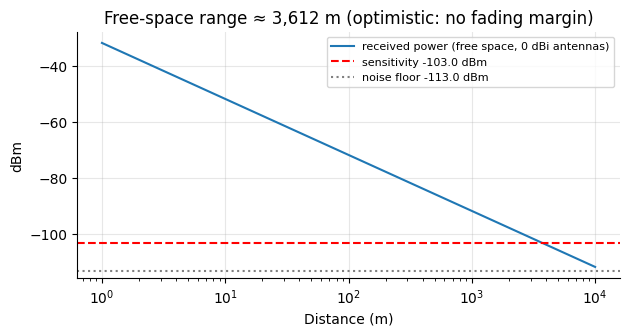

In [12]:
def sensitivity(bw_khz=200.0, nf_db=8.0, snr_req_db=10.0, fc_mhz=915.0, ptx_dbm=0.0):
    floor = -174 + 10 * np.log10(bw_khz * 1e3) + nf_db
    pmin = floor + snr_req_db
    d = np.logspace(0, 4, 200)
    prx = ptx_dbm - cl.fspl_db(d, fc_mhz * 1e6)
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.semilogx(d, prx, label="received power (free space, 0 dBi antennas)")
    ax.axhline(pmin, color="r", ls="--", label=f"sensitivity {pmin:.1f} dBm")
    ax.axhline(floor, color="gray", ls=":", label=f"noise floor {floor:.1f} dBm")
    dmax = d[np.argmin(np.abs(prx - pmin))]
    ax.set_xlabel("Distance (m)"); ax.set_ylabel("dBm"); ax.legend(fontsize=8)
    ax.set_title(f"Free-space range ≈ {dmax:,.0f} m (optimistic: no fading margin)")
    plt.show()

interact(sensitivity,
         bw_khz=FloatSlider(value=200, min=10, max=20000, step=10, description="B kHz"),
         nf_db=FloatSlider(value=8, min=1, max=15, step=0.5, description="NF dB"),
         snr_req_db=FloatSlider(value=10, min=0, max=30, step=1, description="SNR req"),
         fc_mhz=FloatSlider(value=915, min=70, max=6000, step=5, description="fc MHz"),
         ptx_dbm=FloatSlider(value=0, min=-40, max=10, step=1, description="Ptx dBm"));

## 5. Working with real captures

`gnuradio/gr01_spectrum_iq_capture.py` writes a raw `complex64` file (GNU Radio's
`.cfile` convention) plus a SigMF metadata file. The cell below loads it if it
exists, otherwise it synthesizes a stand-in so the notebook always runs.

No capture found; using a synthetic tone. Run gr01 with --out ../data/capture.cfile


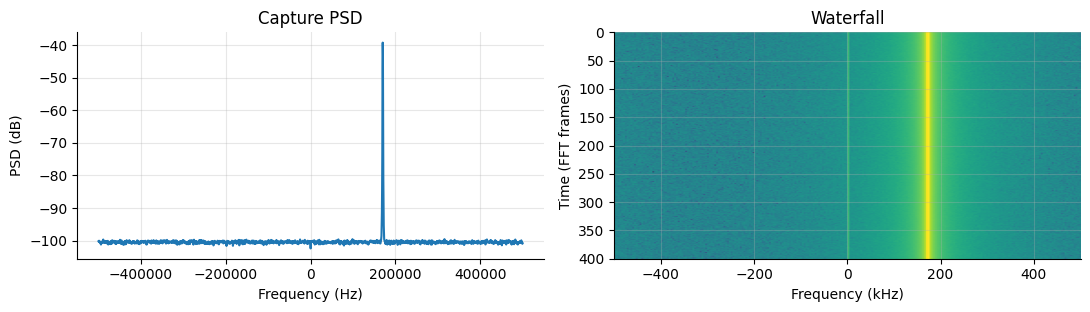

In [14]:
path = os.path.join("..", "data", "capture.cfile")
if os.path.exists(path):
    iq = cl.read_cfile(path, count=2_000_000)
    fs_cap = 1e6
    print(f"Loaded {len(iq):,} samples from {path}")
else:
    fs_cap = 1e6
    iq = cl.awgn(0.3 * np.exp(2j * np.pi * 0.17 * np.arange(200_000)), 30, rng) + 0.01
    print("No capture found; using a synthetic tone. Run gr01 with --out ../data/capture.cfile")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
cl.plot_psd(ax[0], iq, fs_cap, 2048); ax[0].set_title("Capture PSD")
spec = np.abs(np.fft.fftshift(np.fft.fft(iq[:256 * 400].reshape(400, 256), axis=1), axes=1)) ** 2
ax[1].imshow(10 * np.log10(spec + 1e-12), aspect="auto", extent=[-fs_cap / 2e3, fs_cap / 2e3, 400, 0])
ax[1].set_xlabel("Frequency (kHz)"); ax[1].set_ylabel("Time (FFT frames)"); ax[1].set_title("Waterfall")
plt.tight_layout(); plt.show()

## Exercises

1. **(Warm-up)** Show analytically that $\mathrm{IRR} = |\mu|^2/|\nu|^2$ with
   $\mu = (1 + g e^{j\phi})/2$ and $\nu = (1 - g e^{-j\phi})/2$ for the model in `cl.iq_imbalance`. Verify against the slider.
2. **(Core)** Write a blind IQ-imbalance estimator using the moments
   $E[I^2]$, $E[Q^2]$ and $E[IQ]$, apply the inverse 2×2 correction, and measure the
   improvement in IRR on the synthetic signal.
3. **(Core)** Capture 2 s of the FM broadcast band at 100 MHz with gr01 at
   2 MS/s. Identify stations and estimate each one's occupied bandwidth.
4. **(Stretch)** Sweep the B200 RX gain from 0 to 76 dB while receiving a weak
   signal. Plot measured SNR against gain and identify where noise-figure
   improvement stops and where compression begins.